# MILP Selection Analysis

This notebook applies selection criteria, produces the expanded (non-overwriting) dataframe, and generates visualizations.

In [1]:
import pandas as pd
from railpminer.analysis import (
    apply_selection_criteria,
    analyze_lp_models,
    generate_constraint_tables_per_paper,
)
from railpminer.visualization import visualize_single_paper_selected, visualize_paper_matrix_selected

=== LP Model Processing Pipeline ===
Input DataFrame shape: (823, 36)

1. Creating graph representations...
Processing 823 models...
Error parsing model: invalid syntax (<string>, line 2)
variablesInModel=[] 
objective_function=ObjectiveFunction(Name='N/A', Number=0, equation='', description='No objective function found in the provided text.', VariablesIncluded=[]) constraints=[]
Error parsing model: invalid syntax (<string>, line 2)
variablesInModel=[] 
objective_function=ObjectiveFunction(Name='', Number=0, equation='', description='', VariablesIncluded=[]) constraints=[]
Error parsing model: invalid syntax (<string>, line 2)
variablesInModel=[] 
objective_function=ObjectiveFunction(Name='Minimize weighted deviations and cancellations', Number=0, equation='', description='Minimize weighted deviations and cancellations (no explicit algebraic form provided)', VariablesIncluded=[]) constraints=[]
Error parsing model: invalid syntax (<string>, line 2)
variablesInModel=[] 
objective_funct

,minimal_size,graph_diameter,constraint_variable_ratio,model_coherence,model_completeness,model_naivety
count,823.000000,823.000000,823.000000,823.000000,823.000000,823.0
mean,63.417983,5.177400,1.566190,0.821385,0.616039,0.0
std,54.340530,1.612036,0.742780,0.383262,0.486644,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,28.000000,4.000000,1.142857,1.000000,0.000000,0.0
50%,48.000000,5.000000,1.500000,1.000000,1.000000,0.0
75%,85.000000,6.000000,2.000000,1.000000,1.000000,0.0
max,390.000000,14.000000,4.333333,1.000000,1.000000,0.0



=== First Model Visualization ===


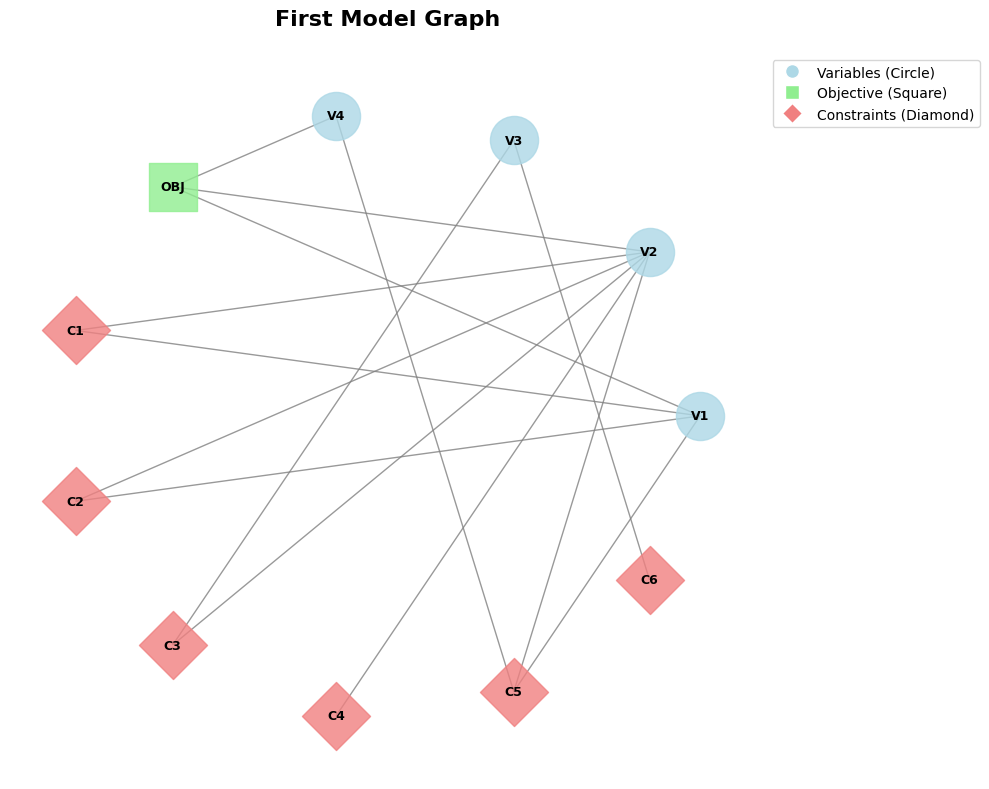

In [2]:
csv_latest = "experiment_results_metrics_corrected_selected.csv"
fig_path_dir = r"C:\Users\joern\GIT\raiLPminer\67531d7506c81a8c34f5794e\figs"

df = pd.read_csv(csv_latest)
df_processed = analyze_lp_models(df, graph_column='graph')

## Filtering & Selection Criteria

In [ ]:
# Filter for quality models
df_filtered = df_processed[
    (df_processed['corrected_completeness'] != 0) &
    (df_processed['model_coherence'] != 0)
]

# Parameter variation: only Paper_1
df_filtered_parameter = df_filtered[
    df_filtered['paper'].str.contains('1', na=False)
]

# Paper variation: fixed model/temp/workflow across papers
df_filtered_paper = df_filtered[
    (df_filtered['temperature'] == 1.0) &
    (df_filtered['workflow'].str.contains('ZS', na=False)) &
    (df_filtered['model'].str.contains('openai_o4_mini', na=False))
]

criteria_1 = [
    ('minimal_size', 'max'),
    ('minimal_size', 'min'),
    ('constraint_variable_ratio', 'max'),
    ('graph_diameter', 'max'),
]

## Apply Selection (Parameter Variation)

In [4]:
df_processed, df_expanded_parameter = apply_selection_criteria(
    df_full=df_processed.copy(),
    df_filtered=df_filtered_parameter,
    group_column='paper',
    criteria=criteria_1,
    result_column_name='analysis_parameter',
)

print(f"df_processed rows with analysis_parameter != 'none': "
      f"{(df_processed['analysis_parameter'] != 'none').sum()}")
print(f"df_expanded_parameter rows (one per criterion): {len(df_expanded_parameter)}")
df_expanded_parameter[['paper', 'model', 'workflow', 'temperature', 'analysis_parameter']]

df_processed rows with analysis_parameter != 'none': 4
df_expanded_parameter rows (one per criterion): 4


,paper,model,workflow,temperature,analysis_parameter
579,Paper_1,gemini_pro,ZS,0.2,High Minimal Size
19,Paper_1,deepseek_v3,ZS,0.6,Low Minimal Size
23,Paper_1,deepseek_v3,ZS,0.6,High Graph Diameter
692,Paper_1,gemini_pro,ZS,0.6,High Constraint Variable Ratio


## Apply Selection (Paper Variation)

In [5]:
df_processed, df_expanded_paper = apply_selection_criteria(
    df_full=df_processed,
    df_filtered=df_filtered_paper,
    group_column='paper',
    criteria=criteria_1,
    result_column_name='analysis_paper',
)

print(f"df_processed rows with analysis_paper != 'none': "
      f"{(df_processed['analysis_paper'] != 'none').sum()}")
print(f"df_expanded_paper rows (one per criterion): {len(df_expanded_paper)}")
df_expanded_paper[['paper', 'model', 'workflow', 'temperature', 'analysis_paper']]

df_processed rows with analysis_paper != 'none': 18
df_expanded_paper rows (one per criterion): 20


,paper,model,workflow,temperature,analysis_paper
123,Paper_1,openai_o4_mini,ZS,1.0,High Minimal Size
124,Paper_1,openai_o4_mini,ZS,1.0,Low Minimal Size
120,Paper_1,openai_o4_mini,ZS,1.0,High Graph Diameter
116,Paper_1,openai_o4_mini,ZS,1.0,High Constraint Variable Ratio
768,Paper_2,openai_o4_mini,ZS,1.0,High Minimal Size
767,Paper_2,openai_o4_mini,ZS,1.0,Low Minimal Size
768,Paper_2,openai_o4_mini,ZS,1.0,High Graph Diameter
769,Paper_2,openai_o4_mini,ZS,1.0,High Constraint Variable Ratio
791,Paper_3,openai_o4_mini,ZS,1.0,High Minimal Size
784,Paper_3,openai_o4_mini,ZS,1.0,Low Minimal Size


In [ ]:
df_processed.to_csv(csv_latest, index=False)
print(f"Saved to {csv_latest}")

## Visualize Single Paper (Parameter Variation)

Saved to: C:\Users\joern\GIT\raiLPminer\67531d7506c81a8c34f5794e\figs/single_paper_parameter.pdf


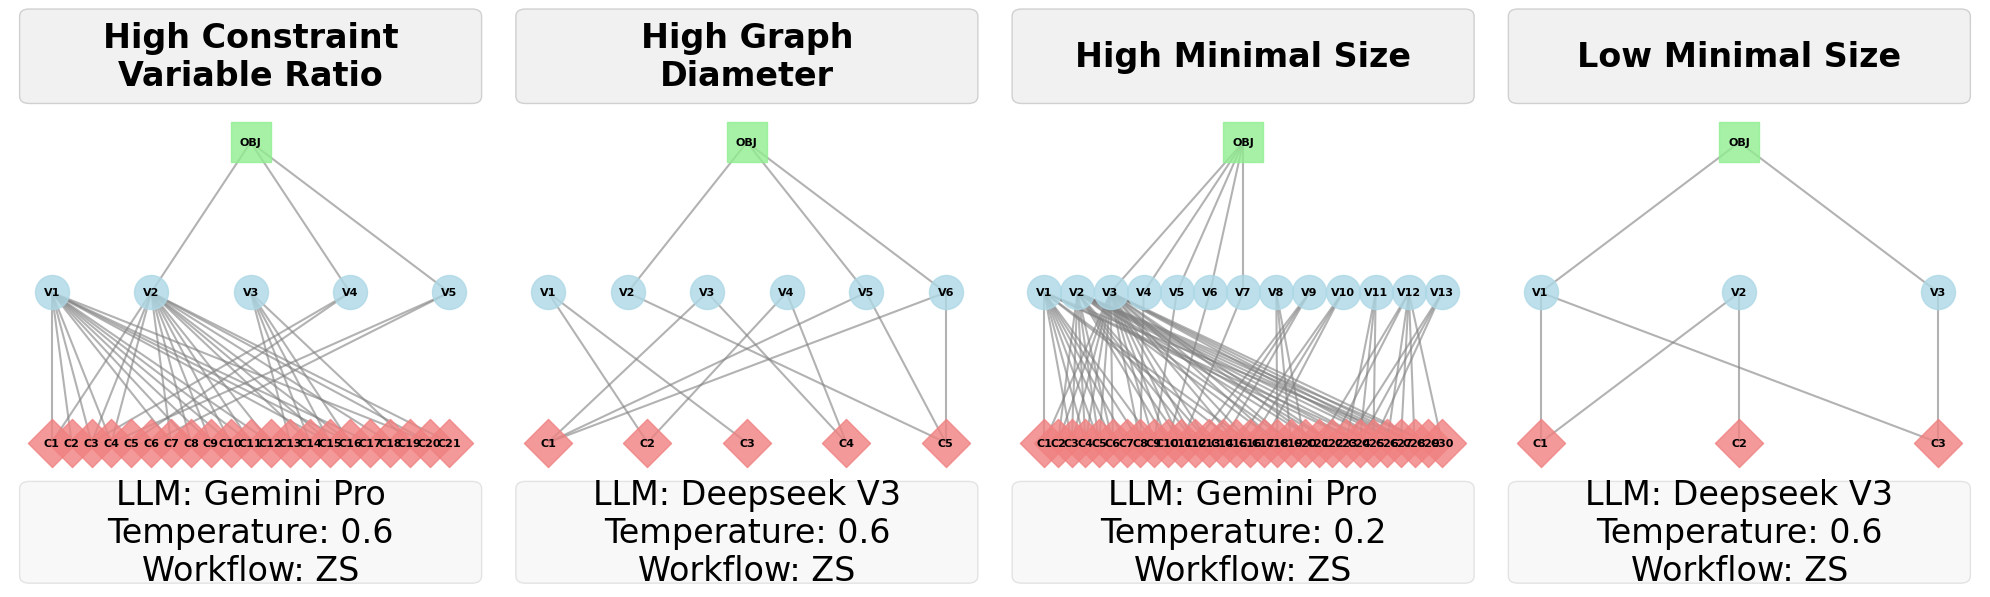

In [6]:
visualize_single_paper_selected(
    df_processed,
    "Paper_1",
    save_path=f"{fig_path_dir}/single_paper_parameter.pdf",
)

## Visualize Paper Matrix (Paper Variation)

Saved to: C:\Users\joern\GIT\raiLPminer\67531d7506c81a8c34f5794e\figs/paper_matrix.pdf


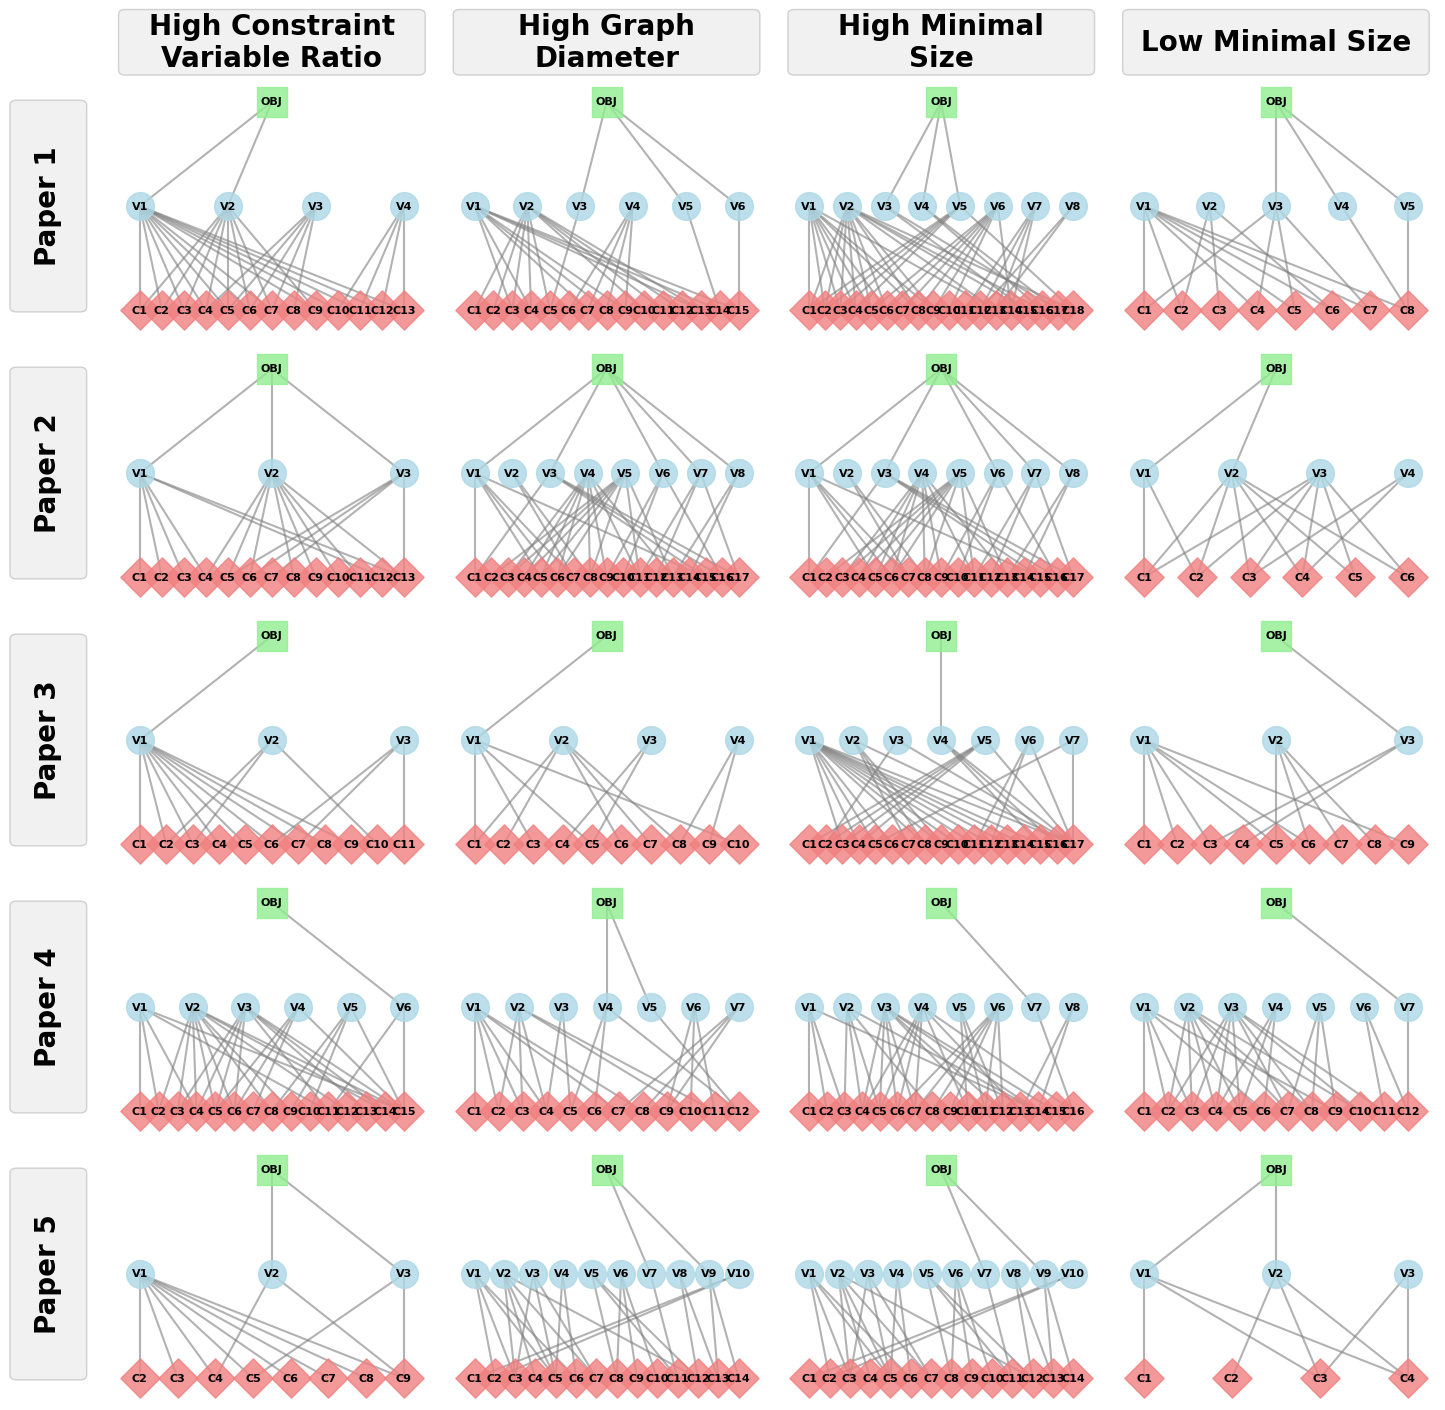

In [7]:
visualize_paper_matrix_selected(
    df_expanded_paper,
    save_path=f"{fig_path_dir}/paper_matrix.pdf",
)

## Constraint Tables (Parameter Variation)

Uses `df_expanded_parameter` so that MILPs fulfilling multiple criteria appear in all relevant columns.

In [8]:
ref_path = r'C:\Users\joern\GIT\raiLPminer\67531d7506c81a8c34f5794e\tables\constraint_reference.csv'

tables_parameter = generate_constraint_tables_per_paper(
    df_expanded_parameter,
    selection_row='analysis_parameter',
    reference_csv_path=ref_path,
    suffix="parametervariation",
)
tables_parameter['Paper_1']

,Paper_1,Low Minimal Size,High Graph Diameter,High Minimal Size,High Constraint Variable Ratio
Constraint Type,,,,,
(Re-)Ordering,x,x,x,x,
(Re-)Routing,,,,,
(Re-)Timing,x,,x,x,x
Cancelling,x,x,x,x,x
Headway,x,x,x,x,x
Capacity,x,x,x,x,
Flow Balance,,,,,
Big-M,x,,x,,
Passenger connection,,,,,


## Constraint Tables (Paper Variation)

Uses `df_expanded_paper` so that MILPs fulfilling multiple criteria appear in all relevant columns.

In [9]:
tables_paper = generate_constraint_tables_per_paper(
    df_expanded_paper,
    selection_row='analysis_paper',
    reference_csv_path=ref_path,
    suffix="papervariation",
)
tables_paper['Paper_1']

,Paper_1,Low Minimal Size,High Graph Diameter,High Minimal Size,High Constraint Variable Ratio
Constraint Type,,,,,
(Re-)Ordering,x,,x,x,x
(Re-)Routing,,,,,
(Re-)Timing,x,x,x,x,x
Cancelling,x,x,x,x,x
Headway,x,x,x,x,x
Capacity,x,,,,x
Flow Balance,,,x,,
Big-M,x,,,,
Passenger connection,,,,,


## Runtime Boxplots

In [10]:
from railpminer.visualization import plot_runtime_boxplots

### Parameter Variation (Paper 1 — model / temperature / workflow)

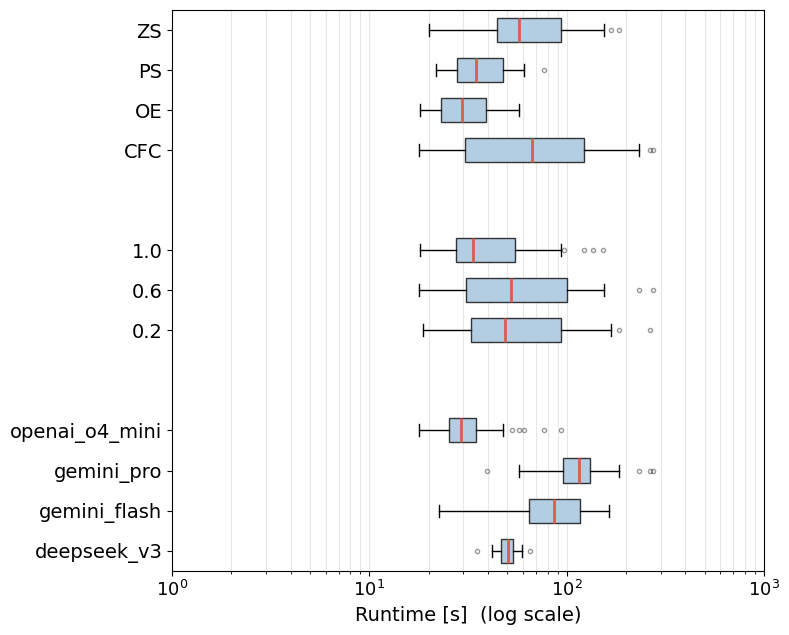

In [11]:
plot_runtime_boxplots(
    df_filtered_parameter,
    categories=["model", "temperature", "workflow"],
    figsize=(8, 6),
    fontsize=14,
    save_path=f"{fig_path_dir}/runtime_boxplots_parameter.pdf",
)

### Paper Variation (openai_o4_mini · ZS · temp=1 — across papers)

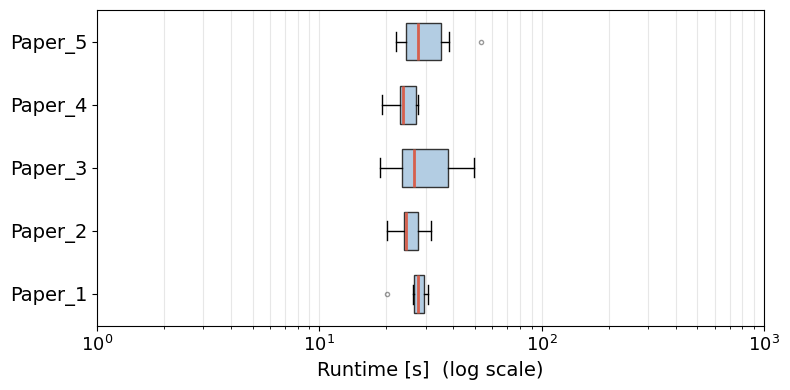

In [12]:
plot_runtime_boxplots(
    df_filtered_paper,
    categories=["paper"],
    figsize=(8, 4),
    fontsize=14,
    save_path=f"{fig_path_dir}/runtime_boxplots_paper.pdf",
)

## Scatter Plots (Constraint Count vs Variable Count)

In [13]:
from railpminer.visualization import create_advanced_scatter_analysis

### Parameter Variation — by Model

In [ ]:
create_advanced_scatter_analysis(
    df_filtered_parameter,
    category_col='model',
    legend=True,
    save_path=f"{fig_path_dir}/scatter_parameter_model.pdf",
)

### Parameter Variation — by Temperature

In [ ]:
create_advanced_scatter_analysis(
    df_filtered_parameter,
    category_col='temperature',
    legend=True,
    save_path=f"{fig_path_dir}/scatter_parameter_temperature.pdf",
)

### Parameter Variation — by Workflow

In [ ]:
create_advanced_scatter_analysis(
    df_filtered_parameter,
    category_col='workflow',
    legend=True,
    save_path=f"{fig_path_dir}/scatter_parameter_workflow.pdf",
)

create_advanced_scatter_analysis(
    df_filtered_paper,
    category_col='paper',
    legend=True,
    save_path=f"{fig_path_dir}/scatter_paper.pdf",
)

In [ ]:
create_advanced_scatter_analysis(
    df_filtered_paper,
    category_col='paper',
    cols=5,
    legend=True,
    font_size=25,
    save_path=f"{fig_path_dir}/scatter_paper.pdf",
)